In [1]:
pip install -U sentence-transformers

In [2]:
from io import IncrementalNewlineDecoder
from sentence_transformers import SentenceTransformer
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
model = SentenceTransformer("clip-ViT-B-32")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

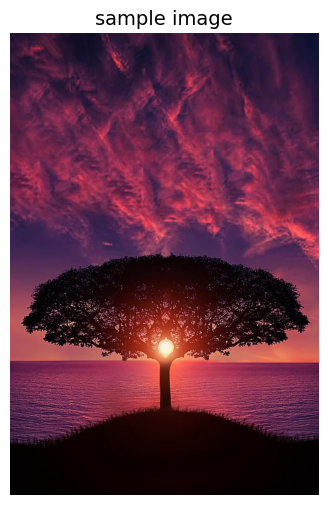

In [39]:
img1 = "/content/1.jpg"
img1 = Image.open(img1)
plt.figure(figsize = (6,6))
plt.imshow(img1)
plt.axis("off")
plt.title("sample image",fontsize=14)
plt.show()


In [52]:
text_description = ["A cat on a table",
                    "A picture of london at night",
                    "A developer working on code with multiple monitors",
                    "A dog sleeping on a cough",
                    "Colorful hot air balloons floating in a clear blue sky",
                    "Two cats fighting in the garden",
                    "An abandoned airplane surrounded by a dense forest",
                    "People crossing the street by the iconic Flatiron Building"]

In [53]:
def display_image_and_compare(image_path,text_description):
  #loading Image
  img = Image.open(image_path)
  # encode text and image(converting both into numbers)
  text_emb = model.encode(text_description)
  img_emb = model.encode(img)
  # Compute similarity score
  similarity_score = np.dot(text_emb,img_emb)
  # find the best match
  best_match_index = np.argmax(similarity_score)
  best_match_desc = text_description[best_match_index]

  # print the final output
  print(f"\nThe Image is most similar to : {best_match_desc} with score of {similarity_score.max()}")

  # Display the image
  plt.figure(figsize = (6,6))
  plt.imshow(img)
  plt.axis('off')
  plt.title("Image for similarity comparison",fontsize=14)
  plt.show()


The Image is most similar to : People crossing the street by the iconic Flatiron Building with score of 24.75473403930664


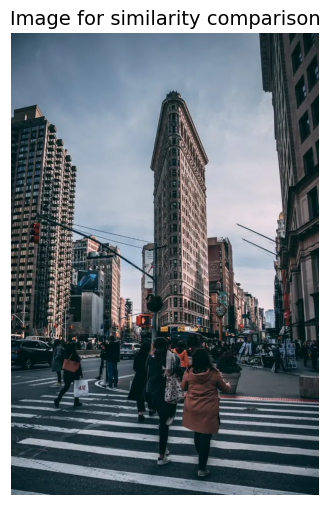

In [54]:
display_image_and_compare("/content/5.webp",text_description)


The Image is most similar to : Colorful hot air balloons floating in a clear blue sky with score of 26.902467727661133


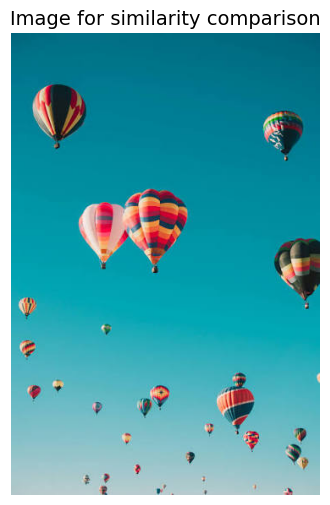

In [55]:
display_image_and_compare("/content/6.jpg",text_description)


The Image is most similar to : An abandoned airplane surrounded by a dense forest with score of 31.432680130004883


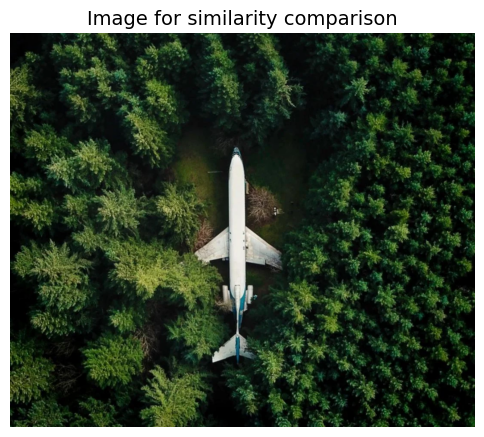

In [56]:
display_image_and_compare("/content/7.webp",text_description)


The Image is most similar to : A developer working on code with multiple monitors with score of 35.111961364746094


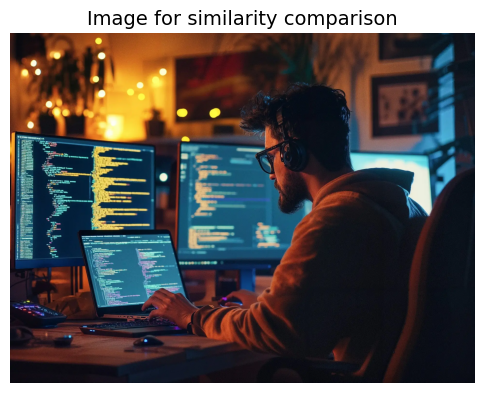

In [57]:
display_image_and_compare("/content/8.webp",text_description)